## American-Job-Quality Study by Gallup ##
- Conducted between January 13 and February 25, 2025.
- Based on self-administered web and mail surveys from a random sample of 18,429 U.S. adults aged 18 to 75 who worked for pay in the prior seven days.
- Nationally representative of workers all over the country.
- A total of 3,040 cases were removed due to ineligibility or data quality issues.


In [4]:
%pip install pandas
%pip install matplotlib
%pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 26.0 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 44.8 MB/s  0:00:00
Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl (4.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
df_labeled = pd.read_csv(
    '/Users/miskatulmoon/Downloads/JFF_formatted_public_release_labels.csv',
    encoding='cp1252'
)

#entries converted to numerical values
df_unlabeled = pd.read_csv(
    '/Users/miskatulmoon/Downloads/JFF_formatted_public_release_values.csv',
    encoding='cp1252'
)

/var/folders/5v/36m4ym_d3492xdw4y3xwfk980000gn/T/ipykernel_24958/2784219826.py:7: DtypeWarning: Columns (5: S1, 148: REGION, 149: DIVISION) have mixed types. Specify dtype option on import or set low_memory=False.
  df_unlabeled = pd.read_csv(


In [6]:
df_labeled.head()

,ENTITY_ID,SAMPLE,MODE,RESPONDENT_DATE,EndDate,S1,Q1,Q2,Q3,Q4,...,RACE6,RACE7,MARITAL_STATUS,EDUCATION,STATE,REGION,DIVISION,WORKER_TYPE,W2_STATUS,WEIGHT
0,4398199396,ABS Mail,Mail,1/28/2025,,,7,7,Very good,6,...,,White,Separated/divorced,High school graduate (high school diploma or e...,MA,Northeast,New England,Employee,W2 Worker,0.988427
1,4398199398,ABS Mail,Mail,1/28/2025,,,10-Completely satisfied,8,Excellent,10-Completely satisfied,...,,White,Married,"Four-year Bachelor's degree (e.g., BA, AB, BS)",MA,Northeast,New England,Employee,W2 Worker,0.184232
2,4398199412,ABS Mail,Mail,1/23/2025,,,8,8,Excellent,8,...,,White,Domestic partnership/Living with partner (not ...,"Advanced degree (Master's, professional, docto...",MA,Northeast,New England,Employee,W2 Worker,0.368465
3,4398199417,ABS Mail,Mail,1/30/2025,,,8,8,Very good,9,...,,White,Married,High school graduate (high school diploma or e...,MA,Northeast,New England,Self-employed IC,Non W2 Worker,3.341439
4,4398199431,ABS Web,Web,,1/16/2025 6:47:11,Yes,6,7,Very good,5,...,,,Domestic partnership/Living with partner (not ...,"Some college, no degree",MA,Northeast,New England,Employee,W2 Worker,1.515829


In [7]:
df_unlabeled.head()

,ENTITY_ID,SAMPLE,MODE,RESPONDENT_DATE,EndDate,S1,Q1,Q2,Q3,Q4,...,RACE6,RACE7,MARITAL_STATUS,EDUCATION,STATE,REGION,DIVISION,WORKER_TYPE,W2_STATUS,WEIGHT
0,4398199396,4,2,1/28/2025,,,7,7,2,6,...,,7,3,2,MA,1,1,1,1,0.988427
1,4398199398,4,2,1/28/2025,,,10,8,1,10,...,,7,2,5,MA,1,1,1,1,0.184232
2,4398199412,4,2,1/23/2025,,,8,8,1,8,...,,7,5,6,MA,1,1,1,1,0.368465
3,4398199417,4,2,1/30/2025,,,8,8,2,9,...,,7,2,2,MA,1,1,4,2,3.341439
4,4398199431,3,1,,1/16/2025 6:47:11,1,6,7,2,5,...,,,5,3,MA,1,1,1,1,1.515829


In [8]:
#unlabeled dataset has 0 missing values because 'No Response" is entered as -98
print("total missing values in unlabeled data:", df_unlabeled.isna().sum().sum())

#labeled dataset preserves NAN values for missing values, so we can see how many missing values are in the dataset
print("total missing values in labeled data:", df_labeled.isna().sum().sum())

total missing values in unlabeled data: 0
total missing values in labeled data: 18630


/var/folders/5v/36m4ym_d3492xdw4y3xwfk980000gn/T/ipykernel_24958/2565754082.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=q4_counts.index.astype(str), y=q4_counts.values, palette="viridis")


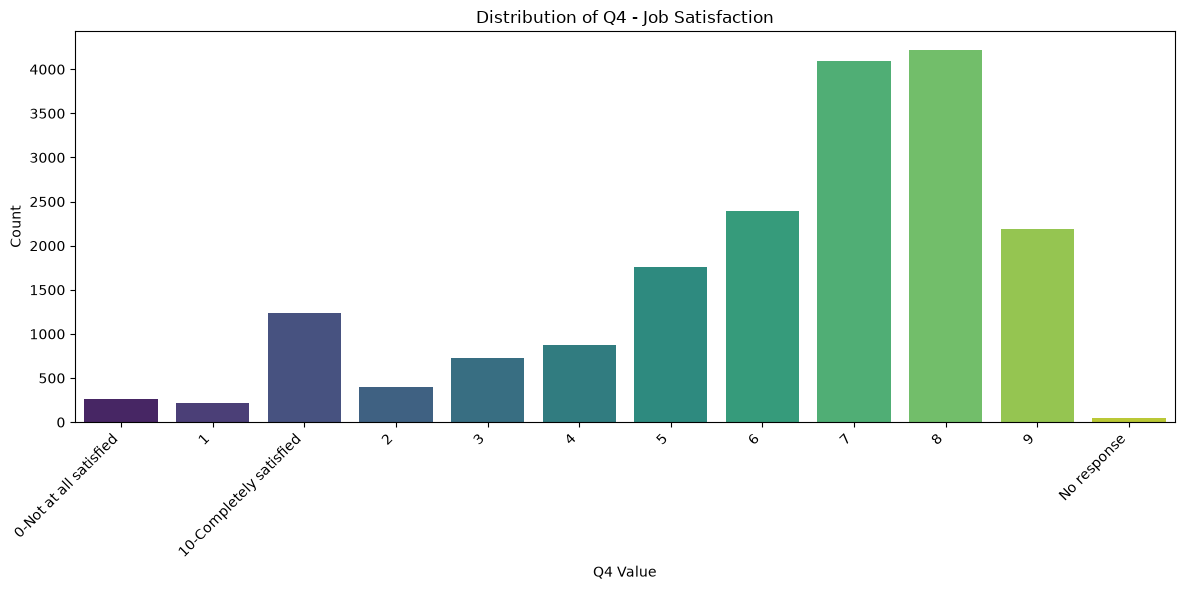

Q4
0-Not at all satisfied      264
1                           217
10-Completely satisfied    1238
2                           396
3                           728
4                           878
5                          1761
6                          2396
7                          4096
8                          4219
9                          2188
No response                  48
Name: count, dtype: int64


In [ ]:
# Distribution of Q4 - our target variable: Job Satisfaction
import matplotlib.pyplot as plt
import seaborn as sns

q4_counts = df_labeled["Q4"].value_counts(dropna=False).sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=q4_counts.index.astype(str), y=q4_counts.values, palette="viridis")
plt.title("Distribution of Q4 - Job Satisfaction")
plt.xlabel("Q4 Value")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(q4_counts)
